# Assignment 3
## Jackie McGinley
### Language Analytics 
#### April 17, 2026

#### Import Packages

In [185]:
import pandas as pd
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

#### Q1: Ingest and process the customer reviews dataset

#### A1:

In [186]:
cust_rev = pd.read_csv("customer_reviews.csv")
cust_rev.head()

,Unnamed: 0,reviewContent,rating
0,0,Let me begin by saying that there are two kind...,5
1,1,The only place inside the Loop that you can st...,3
2,2,I have walked by the Tokyo Hotel countless tim...,5
3,3,"If you are considering staying here, watch thi...",1
4,4,"This place is disgusting, absolutely horrible,...",3


In [187]:
cust_rev.info()
cust_rev.describe()
cust_rev['rating'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Unnamed: 0     2500 non-null   int64 
 1   reviewContent  2500 non-null   object
 2   rating         2500 non-null   int64 
dtypes: int64(2), object(1)
memory usage: 58.7+ KB


rating
4    1020
5     530
3     493
2     287
1     170
Name: count, dtype: int64

In [188]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text

cust_rev['clean_review'] = cust_rev['reviewContent'].apply(clean_text)

In [189]:
def remove_stopwords(text):
    return " ".join([word for word in text.split() if word not in ENGLISH_STOP_WORDS])

cust_rev['clean_review'] = cust_rev['clean_review'].apply(remove_stopwords)

#### Q2: Create a binary class target column called pos_rev that is 1 if the rating is 4 or 5 and 0 otherwise. Set this as the target column (i.e. y).

#### A2:

In [190]:
cust_rev['pos_rev'] = cust_rev['rating'].apply(lambda x: 1 if x >= 4 else 0)

y = cust_rev['pos_rev']

cust_rev[['rating', 'pos_rev']].head()

,rating,pos_rev
0,5,1
1,3,0
2,5,1
3,1,0
4,3,0


#### Q3: Split the data into train and test sets with an 80/20 split.

#### A3:

In [191]:
X = cust_rev['clean_review']
y = cust_rev['pos_rev']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#### Q4: Transform text using sklearn's CountVectorizer as a method of feature extraction.

#### A4:

In [192]:
vectorizer = CountVectorizer(max_features=5000)

X_train_vec = vectorizer.fit_transform(X_train)

X_test_vec = vectorizer.transform(X_test)

X_train_df = pd.DataFrame(X_train_vec.toarray(), columns=vectorizer.get_feature_names_out())

X_train_df.head()

,aaa,ability,able,absolute,absolutely,absurd,abundance,abundant,ac,accents,...,youth,youve,yr,yum,yummy,yup,zebra,zero,zest,zoo
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


#### Explain how CountVectorizer works. How does it transform the text into numeric values?

#### CountVectorizer is used to convert text data into numerical features. It creates a vocabulary of unique words in the training datas and then representing each document as a vector of word counts. Each column in the resulting matrix corresponds to a specific word, and each row represents a document. The values in the matrix indicate how many times each word appears in a given document. This approach is known as the “bag-of-words” model. It ignores word order and focuses only on word frequency. The output is a matrix where most values are zero, since each document contains only a subset of all possible words.

#### Q5: Fit and train a classification model with the following classification algorithms: logistic regression, naive bayes, and SGD classifier.

#### A5:

#### Logistic Regression

In [193]:
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train_vec, y_train)

lr_preds = lr_model.predict(X_test_vec)

#### Naïve Bayes

In [194]:
nb_model = MultinomialNB()

nb_model.fit(X_train_vec, y_train)

nb_preds = nb_model.predict(X_test_vec)

#### SGD Classifier

In [195]:
sgd_model = SGDClassifier(random_state=42)

sgd_model.fit(X_train_vec, y_train)

sgd_preds = sgd_model.predict(X_test_vec)

#### Q6: Evaluate and compare the models' performance. What are the accuracy scores for each model? Create a plot that shows the F1 scores of the three different algorithms.

#### A6:

#### Metrics

In [196]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_preds))
print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_preds))
print("SGD Accuracy:", accuracy_score(y_test, sgd_preds))

Logistic Regression Accuracy: 0.758
Naive Bayes Accuracy: 0.8
SGD Accuracy: 0.756


#### Comparison Table

In [197]:
results = {
    "Model": ["Logistic Regression", "Naive Bayes", "SGD"],
    "Accuracy": [
        accuracy_score(y_test, lr_preds),
        accuracy_score(y_test, nb_preds),
        accuracy_score(y_test, sgd_preds)
    ]
}

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy
0,Logistic Regression,0.758
1,Naive Bayes,0.800
2,SGD,0.756


#### Q7: Transform text using sklearn's TfidfVectorizer and go through steps #4, #5, and #6. Compare the performance of the models using CountVectorizer vs. TfidfVectorizer.

#### A7:

In [198]:
tfidf = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

(2000, 5000)
(500, 5000)


### Train

#### Logistic Regression

In [199]:
lr_tfidf = LogisticRegression(max_iter=1000, random_state=42)
lr_tfidf.fit(X_train_tfidf, y_train)
lr_tfidf_preds = lr_tfidf.predict(X_test_tfidf)

#### Naive Bayes

In [200]:
nb_tfidf = MultinomialNB()
nb_tfidf.fit(X_train_tfidf, y_train)
nb_tfidf_preds = nb_tfidf.predict(X_test_tfidf)

#### SGD Classifier

In [201]:
sgd_tfidf = SGDClassifier(random_state=42)
sgd_tfidf.fit(X_train_tfidf, y_train)
sgd_tfidf_preds = sgd_tfidf.predict(X_test_tfidf)

### Evaluate

In [202]:
tfidf_results = {
    "Model": ["Logistic Regression", "Naive Bayes", "SGD Classifier"],
    "Accuracy": [
        accuracy_score(y_test, lr_tfidf_preds),
        accuracy_score(y_test, nb_tfidf_preds),
        accuracy_score(y_test, sgd_tfidf_preds)
    ],
    "Precision": [
        precision_score(y_test, lr_tfidf_preds),
        precision_score(y_test, nb_tfidf_preds),
        precision_score(y_test, sgd_tfidf_preds)
    ],
    "Recall": [
        recall_score(y_test, lr_tfidf_preds),
        recall_score(y_test, nb_tfidf_preds),
        recall_score(y_test, sgd_tfidf_preds)
    ],
    "F1": [
        f1_score(y_test, lr_tfidf_preds),
        f1_score(y_test, nb_tfidf_preds),
        f1_score(y_test, sgd_tfidf_preds)
    ]
}

import pandas as pd
tfidf_results_df = pd.DataFrame(tfidf_results)
tfidf_results_df

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.792,0.785714,0.916667,0.846154
1,Naive Bayes,0.732,0.702273,0.990385,0.821809
2,SGD Classifier,0.746,0.801303,0.788462,0.794830


### Comparison

In [203]:
comparison_df = pd.DataFrame({
    "Vectorizer": [
        "CountVectorizer", "CountVectorizer", "CountVectorizer",
        "TfidfVectorizer", "TfidfVectorizer", "TfidfVectorizer"
    ],
    "Model": [
        "Logistic Regression", "Naive Bayes", "SGD Classifier",
        "Logistic Regression", "Naive Bayes", "SGD Classifier"
    ],
    "Accuracy": [
        accuracy_score(y_test, lr_preds),
        accuracy_score(y_test, nb_preds),
        accuracy_score(y_test, sgd_preds),
        accuracy_score(y_test, lr_tfidf_preds),
        accuracy_score(y_test, nb_tfidf_preds),
        accuracy_score(y_test, sgd_tfidf_preds)
    ],
    "Precision": [
        precision_score(y_test, lr_preds),
        precision_score(y_test, nb_preds),
        precision_score(y_test, sgd_preds),
        precision_score(y_test, lr_tfidf_preds),
        precision_score(y_test, nb_tfidf_preds),
        precision_score(y_test, sgd_tfidf_preds)
    ],
    "Recall": [
        recall_score(y_test, lr_preds),
        recall_score(y_test, nb_preds),
        recall_score(y_test, sgd_preds),
        recall_score(y_test, lr_tfidf_preds),
        recall_score(y_test, nb_tfidf_preds),
        recall_score(y_test, sgd_tfidf_preds)
    ],
    "F1": [
        f1_score(y_test, lr_preds),
        f1_score(y_test, nb_preds),
        f1_score(y_test, sgd_preds),
        f1_score(y_test, lr_tfidf_preds),
        f1_score(y_test, nb_tfidf_preds),
        f1_score(y_test, sgd_tfidf_preds)
    ]
})

comparison_df.sort_values(by="F1", ascending=False)

,Vectorizer,Model,Accuracy,Precision,Recall,F1
3,TfidfVectorizer,Logistic Regression,0.792,0.785714,0.916667,0.846154
1,CountVectorizer,Naive Bayes,0.800,0.817365,0.875000,0.845201
4,TfidfVectorizer,Naive Bayes,0.732,0.702273,0.990385,0.821809
0,CountVectorizer,Logistic Regression,0.758,0.803175,0.810897,0.807018
2,CountVectorizer,SGD Classifier,0.756,0.810458,0.794872,0.802589
5,TfidfVectorizer,SGD Classifier,0.746,0.801303,0.788462,0.794830


#### Which combination of vectorizer and algorithm performs best?

In [204]:
comparison_df.sort_values(by="F1", ascending=False).head(1)

,Vectorizer,Model,Accuracy,Precision,Recall,F1
3,TfidfVectorizer,Logistic Regression,0.792,0.785714,0.916667,0.846154


#### Based on the evaluation metrics and comparison table, the best-performing combination was TfidfVectorizer + Logistic Regression, because it achieved the highest 0.846154 on the test set.

### Visualization

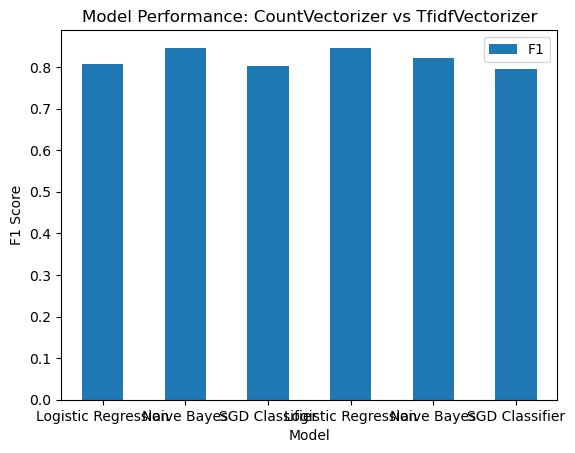

In [205]:
comparison_df.plot(x="Model", y="F1", kind="bar", rot=0)
plt.title("Model Performance: CountVectorizer vs TfidfVectorizer")
plt.ylabel("F1 Score")
plt.show()

#### Are there additional adjustments you can make to further improve the performance? Explain how TfidfVectorizer works. How does it transform the text into numeric values?

#### Additional adjustments that can improve performance include tuning vectorizer settings, tuning model hyperparameters, deep diving on the text processing, addressing the class imbalance, utilizing cross-validation techniques, and potential implementation of a pipeline that includes grid search.

#### TfdifVectorizer converts text into numerical features using a method called Term Frequency–Inverse Document Frequency (TF-IDF). It transforms a collection of text documents into a matrix of weighted values that represent how important each word is in each document. It starts off by building a vocabulary with creating a list of unique words. Then it counts the frequency of the words. It then adjusts the counts based on how common the word is across all documents. Words that appear in many documents have lower importance, whereas words that appear in few documents have higher importance. Once each word gets a weight; common and uninformative words hold low weight but rare and meaningful words hold high weight. 
#### After computing TF-IDF, it is show in a fairly simple way. Each document (review) becomes a row, each word in the vocabulary becomes a column, and each cell contains the TF-IDF weight of that word in that document. TfdifVectorization 

#### Q8: Define a function called textclass_pred that takes one argument--open-ended text. The function should use the model you trained above to predict whether the text passed to the function is positive or negative, based on your trained model. The function should return a statement that indicates whether the text passed is positive or negative.

#### A8:

In [206]:
def textclass_pred(text):
    text_vec = tfidf.transform([text])
    
    prediction = lr_tfidf.predict(text_vec)[0]
    prob = lr_tfidf.predict_proba(text_vec)[0][1]
    
    if prediction == 1:
        return f"Positive review (confidence: {prob:.2f})"
    else:
        return f"Negative review (confidence: {1 - prob:.2f})"

#### Examples

In [207]:
textclass_pred("This product is amazing and works perfectly!")

'Positive review (confidence: 0.70)'

In [208]:
textclass_pred("Terrible experience, would not recommend at all.")

'Negative review (confidence: 0.52)'

#### Q9: How could you apply the techniques used here to other text classification problems? What would you need to build the model?

#### A9:

#### The techniques used could be applied to other text classification problems, such as email filing with spam vs not spam, reviews or social media with positiive vs negative sentiment, topic classification whether that be sports, politics, or technology, etc. What is needed to build the model is a labeled dataset, then completion of text processing, then feature extraction, after that would be machine learning modeling and evaluation metrics, and lastly prediction on new data would be completed. 